In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')


In [3]:
df.head()


,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [6]:
# 2. Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [7]:
# 2. Split and Scale
# Scaling is MANDATORY for KNN because it is distance-based
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 3. Train KNN Model
# n_neighbors=5 is a standard starting point
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [11]:
# 4. Predict and Evaluate
y_pred = knn_model.predict(X_test_scaled)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")
print(f"MAE:      {mae:.2f} MPa")

R2 Score: 0.9439
RMSE:     34.26 MPa
MAE:      27.57 MPa


### Evaluating KNN with Different `k` Values

To find the optimal number of neighbors (`k`) for the K-Nearest Neighbors (KNN) regressor, we'll train and evaluate the model with a range of `k` values. We will plot the R2 score and Root Mean Squared Error (RMSE) for each `k` to observe how performance changes.

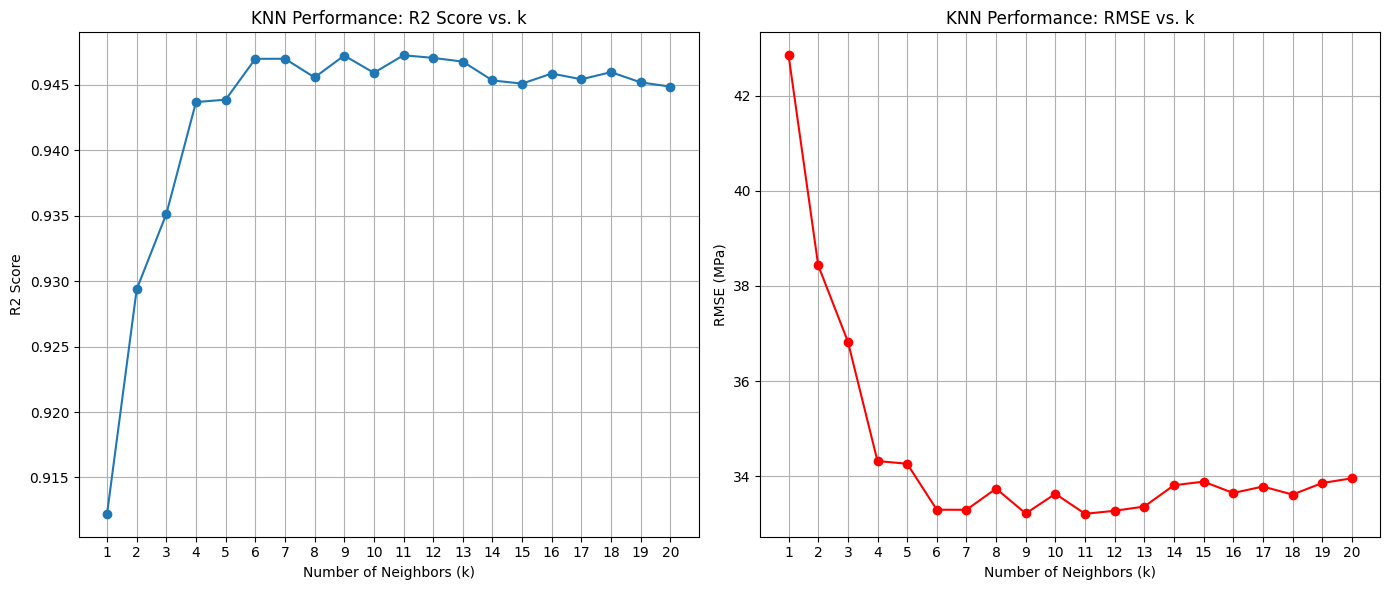

In [16]:
r2_scores = []
rmse_values = []
k_range = range(1, 21) # Test k from 1 to 20

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)

    r2_scores.append(r2_score(y_test, y_pred_k))
    rmse_values.append(np.sqrt(mean_squared_error(y_test, y_pred_k)))

# Plotting the results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, r2_scores, marker='o', linestyle='-')
plt.title('KNN Performance: R2 Score vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.xticks(k_range)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, rmse_values, marker='o', linestyle='-', color='red')
plt.title('KNN Performance: RMSE vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE (MPa)')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

The plots above show how the R2 score and RMSE change as the number of neighbors (`k`) varies. Ideally, we are looking for a `k` value that maximizes the R2 score and minimizes the RMSE. By inspecting these plots, we can determine a suitable `k` for our model.

### Refitting KNN with Optimal `k`

Based on the plots, an optimal `k` value of 7 seems to provide a good balance between R2 score and RMSE. We will now refit the model with this `k` and evaluate its performance.

In [17]:
# Optimal k value identified from the plots
optimal_k = 7

# Refit KNN Model with optimal k
knn_optimal_model = KNeighborsRegressor(n_neighbors=optimal_k)
knn_optimal_model.fit(X_train_scaled, y_train)

# Predict and Evaluate with optimal k
y_pred_optimal = knn_optimal_model.predict(X_test_scaled)

r2_optimal = r2_score(y_test, y_pred_optimal)
rmse_optimal = np.sqrt(mean_squared_error(y_test, y_pred_optimal))
mae_optimal = mean_absolute_error(y_test, y_pred_optimal)

print(f"KNN Model with Optimal k={optimal_k}:")
print(f"R2 Score: {r2_optimal:.4f}")
print(f"RMSE:     {rmse_optimal:.2f} MPa")
print(f"MAE:      {mae_optimal:.2f} MPa")

KNN Model with Optimal k=7:
R2 Score: 0.9470
RMSE:     33.30 MPa
MAE:      26.68 MPa


### Cross-Validation for Optimal KNN Model

To further assess the robustness and generalization ability of our KNN model with the optimal `k=7`, we will perform k-fold cross-validation. This technique helps in getting a more reliable estimate of the model's performance by training and evaluating it on different subsets of the data.